In [1]:
import importlib
import quantum_function
importlib.reload(quantum_function)

from quantum_function import *
from IPython.display import display, Markdown

In [2]:
# --- SAFETY SWITCH: esce subito se non abiliti esplicitamente ---
RUN_THIS_CELL = True   # metti True solo quando vuoi davvero eseguire

if not RUN_THIS_CELL:
    display(Markdown("Cell locked. Set `RUN_THIS_CELL = True` to run"))
    raise SystemExit



plt.rcParams["text.usetex"] = True
plt.rcParams.update({
    "mathtext.fontset": "cm",      # font simile a LaTeX
    "font.family": "serif",
    "font.size": 14,
    "axes.unicode_minus": False
})

In [ ]:
#PARAMETERS!

gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

step = 0.005
endpoint = 20 
times = np.array(np.arange(0, endpoint*T_1, step*T_1)) 


my_label_states = ["Css_pi/2", "Css_pi/3", "Css_pi/4", "Css_pi/6"] 
my_theta = [np.pi/2, np.pi/3, np.pi/4, np.pi/6]  # angles for the CSS states
my_initial_states = [css_2(theta, phi=0) for theta in my_theta]


eta=0.8  # efficiency for the photodetection!
#my_label_eta = ["1", "0.9", "0.5", "0.3"]
#my_eta = [1, 0.9, 0.5, 0.3] #etas for the homodyne detection

my_opts_dict = {
    "keep_runs_results": False,
    #"map":"parallel",
    #"normalize_output" : False,
    #"store_final_state" : False,
    #"store_states": False,
    #"store_measurement": False,
    #"progress_bar": "Enhanced",
    "num_cpus": os.cpu_count()-1,
    }

columns_label = [
                #"Energy",
                 "Conc",
                 #"Xi2_KU",
                 #"F_phi_plus",
                 #"F_phi_minus",
                 #"F_psi_plus",
                 #"F_psi_minus",
                #"Variance_z"
            ]

label_graph_column = {
    #"Energy": r"Energy",
    "Conc": r"$\overline{\mathcal{C}}$",
    #"Xi2_KU": r"$\xi^2_{KU}$",
    #"F_phi_plus": r"Fidelity $|\Phi^+\rangle$",
    #"F_phi_minus": r"Fidelity $|\Phi^-\rangle$",
    #"F_psi_plus": r"Fidelity $|\Psi^+\rangle$",
    #"F_psi_minus": r"Fidelity $|\Psi^-\rangle$",
    #"Variance_z": r"$\mathrm{Var}(J_z)$"
}

my_e_ops = [
    #energy_solver, 
    concurrence_for_solver_general, 
    #xi_KU_solver,
    #Variance_z
    ]

<font size="6">***Inefficient photodetection - 2 qubits, single dephasing***

## Inefficient case: $|+ \! + \rangle$, $\quad \phi_1 = 0 \quad \phi_2 = 0$

$$
\left\{
\begin{aligned}
\hat{C}_1 &= e^{i \phi_{1}}\hat{C}_+ = \hat{C}_+\\
\hat{C}_2 &= e^{i \phi_{2}}\hat{C}_- = \hat{C}_-
\end{aligned}
\right.
$$

10.0%. Run time:  38.81s. Est. time left: 00:00:05:49
20.0%. Run time:  76.96s. Est. time left: 00:00:05:07
30.0%. Run time: 115.45s. Est. time left: 00:00:04:29
40.0%. Run time: 153.42s. Est. time left: 00:00:03:50
50.0%. Run time: 191.40s. Est. time left: 00:00:03:11
60.0%. Run time: 229.46s. Est. time left: 00:00:02:32
70.0%. Run time: 268.64s. Est. time left: 00:00:01:55
80.0%. Run time: 306.99s. Est. time left: 00:00:01:16
90.0%. Run time: 345.39s. Est. time left: 00:00:00:38
100.0%. Run time: 383.93s. Est. time left: 00:00:00:00
Total run time: 384.34s
10.0%. Run time:  38.33s. Est. time left: 00:00:05:44
20.0%. Run time:  77.60s. Est. time left: 00:00:05:10
30.0%. Run time: 116.37s. Est. time left: 00:00:04:31
40.0%. Run time: 155.25s. Est. time left: 00:00:03:52
50.0%. Run time: 193.97s. Est. time left: 00:00:03:13
60.0%. Run time: 232.71s. Est. time left: 00:00:02:35
70.0%. Run time: 271.56s. Est. time left: 00:00:01:56
80.0%. Run time: 309.66s. Est. time left: 00:00:01:17
90.

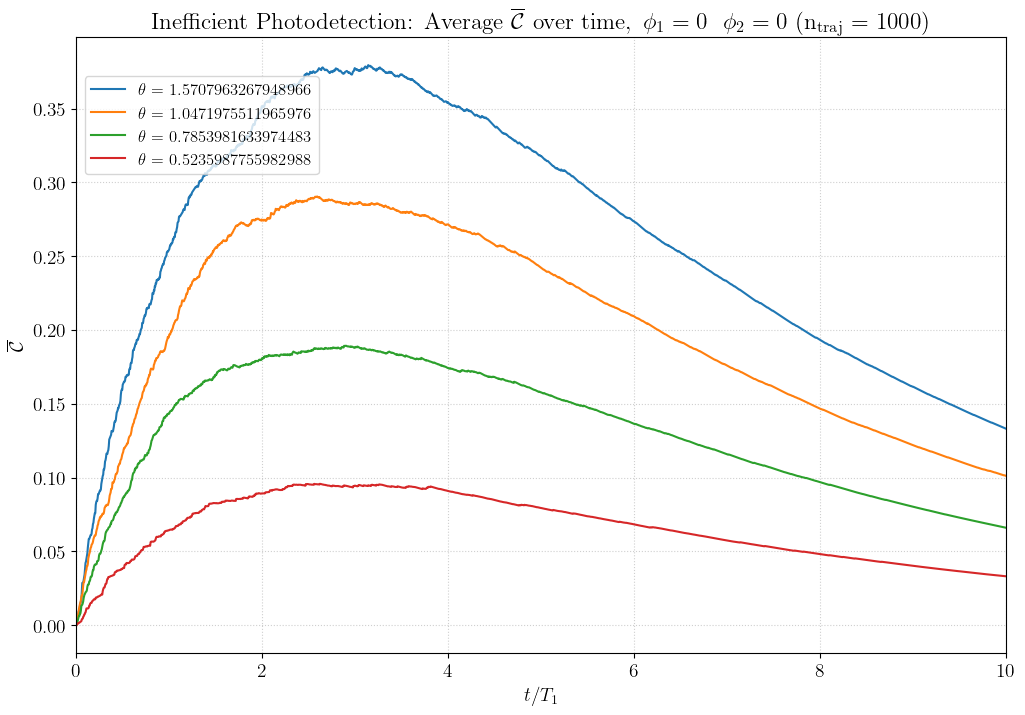

In [25]:
my_phis =[
    [0,0], 
    #[0, np.pi/2], 
    #[np.pi/2,0], 
    #[np.pi/2, np.pi/2]
    ]

ntraj = 1000

for phi_pair in my_phis:

    phi1, phi2 = phi_pair
    ineff_df = {}

    for state,label in zip(my_initial_states, my_label_states):

        my_photodetection = mcsolve(
            qutip.liouvillian(H_free, collapsing_operators(gamma, phi1, phi2, 1-eta)), 
            state, times,

            c_ops = collapsing_operators(gamma, phi1, phi2, eta),
            
            e_ops=my_e_ops,
            ntraj=ntraj,
            options=my_opts_dict
        )

        ineff_df[f"{label}"] = pd.DataFrame(np.transpose(my_photodetection.expect), columns=columns_label)

    
    #Setting the path to save the graphs
    phi1_dir = angle_to_path(phi1)
    phi2_dir = angle_to_path(phi2)
    my_directory = f".\\Graphs\\Jz_3_Ineff_Photodetection_SIM_states\\phi_1={phi1_dir}_phi_2={phi2_dir}"
    Path(my_directory).mkdir(parents=True, exist_ok=True)

    #My theoretical curves
    #theo_curves = [np.sin(css_theta)**2 * np.exp(-(1-eta)*times)*(1-np.exp(-gamma*eta/2*times)) for eta in my_eta]
    theo_curves_states = [0.5*np.sin(theta)**2 * np.exp(-eta*gamma*times/2) + (1-np.exp(-eta*gamma*times/2))*(np.cos(theta/2)**4+np.sin(theta/2)**4)*np.sin(theta)**4/(1+np.cos(theta)**2)**2 for theta in my_theta]


    #Plotting!
    for e_op in columns_label:
        #Un graph per ogni e_op, al variare di eta
        plt.figure(figsize=(12,8))
        graph_name = f"Ineff_{e_op}"

        for (label, df), theta, theory in zip(ineff_df.items(), my_theta, theo_curves_states):
            # x: tempo normalizzato a T1, y: media delle traiettorie
            x = times/T_1
            y = df[e_op]
            line_sim, = plt.plot(x, y, label=r"$\theta$ = " + str(theta))
            #plt.plot(times/T_1, theory, '--', color=line_sim.get_color(), alpha=0.5, linewidth=2)

        #plt.ylim(-0.01, 1.02)
        plt.xlim(0,endpoint)

        #plt.axhline(1, color="k", linewidth=1.6, linestyle="-", zorder=5)
        #plt.axhspan(1, 1.05, color="k", alpha=0.7, zorder=1, label="_nolegend_")

        plt.xlabel(r"$t/T_1$")
        plt.ylabel(label_graph_column[e_op])

        phi1_tex = angle_to_tex(phi1)
        phi2_tex = angle_to_tex(phi2)

        plt.title(r"Inefficient Photodetection: Average " + label_graph_column[e_op]+ r" over time"+ rf"$, \ \phi_1={phi1_tex}\ \ \phi_2={phi2_tex}$"
            + rf"  (n$_\mathrm{{traj}}$ = {ntraj})")
        plt.grid(True, linestyle=":", alpha=0.6)
        plt.legend(loc="upper left", bbox_to_anchor=(0, 0.95), fontsize=12)

        plt.savefig(Path(my_directory) / f"{graph_name}.pdf", bbox_inches="tight")
        plt.show()